In [1]:
# carregando livrarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_reduced.csv")

In [3]:
df.shape

(5320, 11)

In [4]:
# Definindo os features e mostrando o cabecario e 5 linhas
features = ['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide', 'quality']
X = df[features].copy()
X.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide,quality
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,1.594818,-1.753919,5
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,2.565734,-0.786828,5
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,2.061356,-1.345931,5
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,1.865803,-1.191760,6
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,1.426692,-1.599748,5


In [5]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-2.16451528, -0.69969941,  0.52388033,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.44699582, -1.33716057, -0.90449728],
       [-2.16451528, -0.54413546,  1.12073572,  0.76375321, -0.15379707,
         0.97938943, -0.63183308,  2.32791859, -0.59986579, -0.90449728],
       [-1.89267181, -0.61080573,  0.95795697,  0.83120168,  0.22035144,
         0.77902725, -0.63183308,  1.87029052, -1.02611677, -0.90449728],
       [ 1.64129325, -0.69969941,  0.49675054,  1.16844407, -0.40322942,
         0.31151549, -0.63183308,  1.69286382, -0.90857958,  0.23226755],
       [-2.16451528, -0.72192284,  0.49675054,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.29445313, -1.21962337, -0.90449728]])

In [6]:
# Estimando um valor inicial para `bandwidth`
bandwidth_estimado = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=1000)
bandwidth_estimado

bandwidth_escolhido = bandwidth_estimado if bandwidth_estimado > 0 else 1.0
bandwidth_escolhido

meanshift = MeanShift(bandwidth=bandwidth_escolhido)
meanshift.fit(X_scaled)

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(3.176357012784454)
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",False
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary <n_jobs>` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers.","ndarray[float64](14, 10)","[[-0.03,-0.12,-0.28,...,-0.36, 0.14, 0.08], [ 1.62,-0.7 , 9.44,..., 1.09,-1.06,-0.42], [ 4.63, 3.25,-0.61,..., 0.57, 0.46, 0.23], ..., [-0.26, 5.9 ,-0.1 ,..., 0.28, 0.74, 0.23], [-0.47,-0.48,-0.26,...,-0.86,10.94,-3.18], [-2.16,-0.86, 5.71,..., 1.59,-1.23,-3.18]]"
"labels_ labels_: ndarray of shape (n_samples,)Labels of each point.","ndarray[int64](5320,)","[0,0,0,...,0,0,0]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10


In [7]:
# Inspecionar resultado modelo ajustado
print('Quantidade de centros encontrados:', len(meanshift.cluster_centers_))
print('\nCentros dos clusters no espaço padronizado:')
print(meanshift.cluster_centers_)


Quantidade de centros encontrados: 14

Centros dos clusters no espaço padronizado:
[[-0.02855033 -0.11598581 -0.28479083 -0.34209226 -0.06635475 -0.24299276
   0.09277196 -0.35888043  0.13655946  0.07668534]
 [ 1.61702152 -0.70287419  9.43795427  0.81409868 -0.99563123  4.33307074
  -1.07155237  1.09367351 -1.05896949 -0.41731235]
 [ 4.63157139  3.25236572 -0.6065276   0.99082975  0.19956541 -0.71255789
   1.22342091  0.56891538  0.4614346   0.23226755]
 [ 1.70925412 -0.64414086  8.36438971  1.18530619  0.06445622  1.04617683
  -0.42100876  1.59326115 -1.45944585 -0.90449728]
 [-0.22763058 -0.6885877   1.4462932   0.89865016 -1.83746538  9.56156962
  -0.58966822  1.22958867 -0.12541432 -0.33611486]
 [ 9.11698859 -0.65525257 -0.94112834 -0.97304507  0.22035144  0.11115331
   1.39208036 -0.45978782  0.10947892  0.23226755]
 [ 6.19467132 -0.09966703 -0.58844107 -1.46879138 -1.21388452 -0.69029543
   2.1510479  -0.17186913  2.3430479   0.23226755]
 [ 4.63157139 -0.36634809 15.01118833  1.7

In [8]:
# Obtendo os clusters do conjunto principal
df['cluster'] = meanshift.labels_
df.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide,cluster
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,5,red,1.594818,-1.753919,0
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,5,red,2.565734,-0.786828,0
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,5,red,2.061356,-1.345931,0
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,6,red,1.865803,-1.191760,0
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,5,red,1.426692,-1.599748,0


In [9]:
# Quantos vinhos por cluster
df['cluster'].value_counts().sort_index()

cluster
0     5162
1       17
2       49
3       13
4       10
5        1
6        3
7        1
8        1
9        1
10      17
11      18
12       2
13      25
Name: count, dtype: int64

In [10]:
# Quantos clusters o meanshift encontrou
n_clusters_encontrados = len(np.unique(meanshift.labels_))
print('Número de clusters encontrados:', n_clusters_encontrados)

Número de clusters encontrados: 14


In [11]:
# Avaliação rápida com silhouette score
if len(np.unique(meanshift.labels_)) >= 2:
    sil = silhouette_score(X_scaled, meanshift.labels_)
    print('Silhouette Score:', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: o modelo encontrou menos de 2 clusters.')

Silhouette Score: 0.1796


In [12]:
# Perfil médio de cada cluster
perfil_clusters = df.groupby('cluster')[features].mean().round(2)
perfil_clusters

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide,quality
cluster,,,,,,,,,,
0,-0.04,-0.03,-0.08,-0.04,0.02,-0.04,0.02,-0.03,-0.01,5.81
1,1.39,-0.70,9.03,0.80,-1.05,4.63,-1.05,1.33,-1.34,5.41
2,2.76,1.99,-0.10,1.43,-0.74,0.23,-0.37,0.58,1.04,5.61
3,1.08,-0.22,5.38,1.13,-0.15,1.44,-0.38,1.36,-1.45,5.69
4,0.19,-0.65,1.15,1.09,-1.11,6.30,-0.67,1.81,-0.87,5.60
5,9.12,-0.66,-0.94,-0.97,0.22,0.11,1.39,-0.51,0.14,6.00
6,5.13,-0.61,1.27,-0.76,-1.26,-0.96,-0.18,-0.58,1.50,6.00
7,4.63,-0.37,15.01,1.71,-3.02,9.80,-0.97,1.80,-0.48,4.00
8,3.00,-0.72,15.04,0.76,-1.03,4.85,-0.97,0.54,-1.74,5.00


In [13]:
# Comparando clusters encontrados com o perfil simulado
pd.crosstab(df['color'], df['cluster'])


cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13
color,,,,,,,,,,,,,,
red,1285,17,7,12,10,0,0,1,1,0,1,0,0,25
white,3877,0,42,1,0,1,3,0,0,1,16,18,2,0


In [15]:
# Redução dos dados para 2 dimensões usando PCA

df['cluster'] = meanshift.labels_

from sklearn.decomposition import PCA

# Cria o modelo PCA para reduzir os dados para 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada pelos dois componentes
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2657
Variância explicada pelo PCA 2: 0.2282
Variância explicada acumulada: 0.494


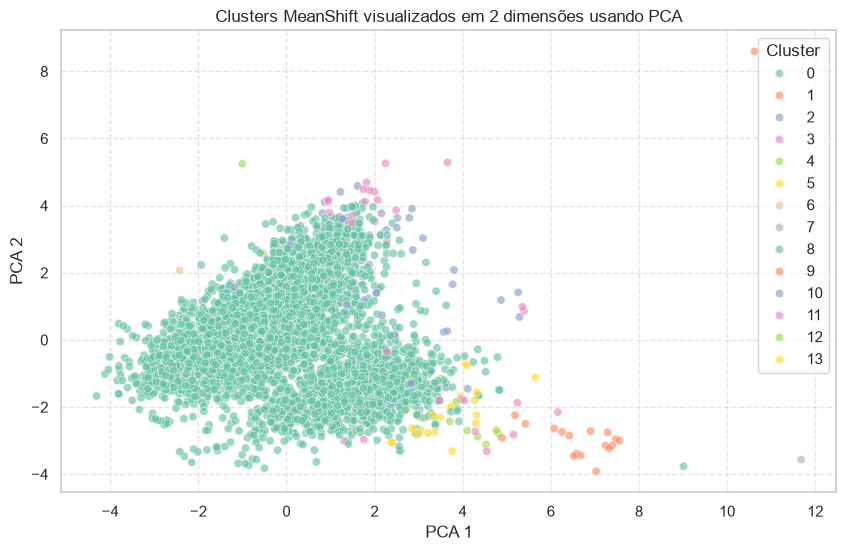

In [16]:
# Adicionando os componentes principais ao DataFrame

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2, colorido pelos clusters do MeanShift

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='Set2',
    alpha=0.65
)

plt.title('Clusters MeanShift visualizados em 2 dimensões usando PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Bandwidth estimado (referência): 3.1647

--- Testando variações de bandwidth ---
Bandwidth: 0.9494 | Clusters: 1672 | Silhouette Score: 0.1134
Bandwidth: 1.4467 | Clusters: 310 | Silhouette Score: -0.0094
Bandwidth: 1.9440 | Clusters: 88 | Silhouette Score: 0.0435
Bandwidth: 2.4413 | Clusters: 31 | Silhouette Score: 0.0805
Bandwidth: 2.9386 | Clusters: 15 | Silhouette Score: 0.1595
Bandwidth: 3.4359 | Clusters: 8 | Silhouette Score: 0.3227
Bandwidth: 3.9333 | Clusters: 6 | Silhouette Score: 0.5039
Bandwidth: 4.4306 | Clusters: 4 | Silhouette Score: 0.5715
Bandwidth: 4.9279 | Clusters: 5 | Silhouette Score: 0.5286
Bandwidth: 5.4252 | Clusters: 4 | Silhouette Score: 0.5593
Bandwidth: 5.9225 | Clusters: 4 | Silhouette Score: 0.5593
Bandwidth: 6.4198 | Clusters: 2 | Silhouette Score: 0.7968
Bandwidth: 6.9171 | Clusters: 2 | Silhouette Score: 0.7968
Bandwidth: 7.4144 | Clusters: 2 | Silhouette Score: 0.7968
Bandwidth: 7.9117 | Clusters: 2 | Silhouette Score: 0.7968

MELHOR CONFIGURAÇÃO ENCO

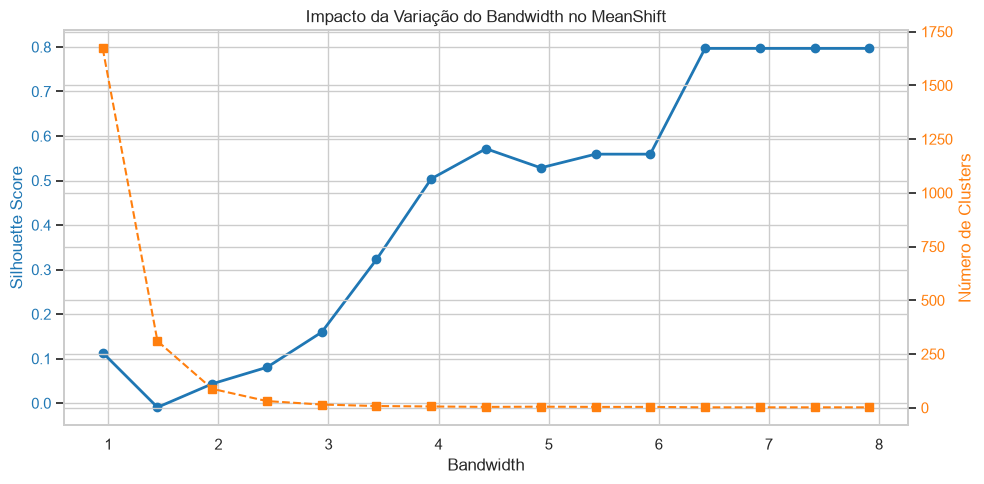

In [14]:
# Configurações iniciais
sns.set_theme(style='whitegrid')
np.random.seed(42)

# Estimativa inicial do bandwidth de referência do scikit-learn
bandwidth_estimado = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=500)
print(f"Bandwidth estimado (referência): {bandwidth_estimado:.4f}\n")

# Definir faixa de busca ao redor da estimativa inicial
# Criando um intervalo contendo valores abaixo e acima do valor estimado
bandwidth_candidates = np.linspace(bandwidth_estimado * 0.3, bandwidth_estimado * 2.5, 15)

results = []

print("--- Testando variações de bandwidth ---")
for bw in bandwidth_candidates:
    # Ajuste do modelo MeanShift
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    cluster_labels = ms.fit_predict(X_scaled)
    
    # Contagem de clusters únicos encontrados
    num_clusters = len(np.unique(cluster_labels))
    
    # O Silhouette Score só pode ser calculado se existirem entre 2 e N-1 clusters
    if 1 < num_clusters < len(X_scaled):
        score = silhouette_score(X_scaled, cluster_labels)
        results.append({
            'bandwidth': bw,
            'silhouette_score': score,
            'n_clusters': num_clusters
        })
        print(f"Bandwidth: {bw:.4f} | Clusters: {num_clusters} | Silhouette Score: {score:.4f}")
    else:
        print(f"Bandwidth: {bw:.4f} | Clusters: {num_clusters} | Score: N/A (inválido para avaliação)")

# Converter resultados em DataFrame
results_df = pd.DataFrame(results)

# Identificar o melhor resultado
if not results_df.empty:
    best_result = results_df.loc[results_df['silhouette_score'].idxmax()]
    print("\n==========================================")
    print("MELHOR CONFIGURAÇÃO ENCONTRADA:")
    print(f"Bandwidth Ótimo: {best_result['bandwidth']:.4f}")
    print(f"Número de Clusters: {int(best_result['n_clusters'])}")
    print(f"Silhouette Score: {best_result['silhouette_score']:.4f}")
    print("==========================================")
    
    # Visualização Gráfica do Desempenho
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Bandwidth')
    ax1.set_ylabel('Silhouette Score', color=color)
    ax1.plot(results_df['bandwidth'], results_df['silhouette_score'], marker='o', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel('Número de Clusters', color=color)
    ax2.plot(results_df['bandwidth'], results_df['n_clusters'], marker='s', linestyle='--', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Impacto da Variação do Bandwidth no MeanShift')
    fig.tight_layout()
    plt.show()

    # Modelo Final Treinado com o melhor bandwidth
    final_model = MeanShift(bandwidth=best_result['bandwidth'], bin_seeding=True)
    df['cluster_meanshift'] = final_model.fit_predict(X_scaled)

else:
    print("\nNão foi possível calcular o Silhouette Score para os valores testados. Tente ajustar o intervalo de 'bandwidth_candidates'.")

In [17]:
# MeanShift final usando o bandwidth ideal

from sklearn.cluster import MeanShift

# Defina aqui o bandwidth ideal encontrado pela avaliação de Silhouette
bandwidth_ideal = best_result['bandwidth']

# Cria o modelo MeanShift final
meanshift_final = MeanShift(
    bandwidth=bandwidth_ideal,
    bin_seeding=True
)

# Treina o modelo e obtém os clusters
clusters_final = meanshift_final.fit_predict(X_scaled)

# Adiciona os clusters finais ao DataFrame
df['cluster_final'] = clusters_final

# Mostra os resultados
print("Bandwidth ideal:", bandwidth_ideal)
print("Número de clusters:", len(np.unique(clusters_final)))

Bandwidth ideal: 6.4197907873551365
Número de clusters: 2


In [18]:
# PCA para redução dos dados para 2 dimensões

from sklearn.decomposition import PCA

# Cria o modelo PCA com 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2657
Variância explicada pelo PCA 2: 0.2282
Variância explicada acumulada: 0.494


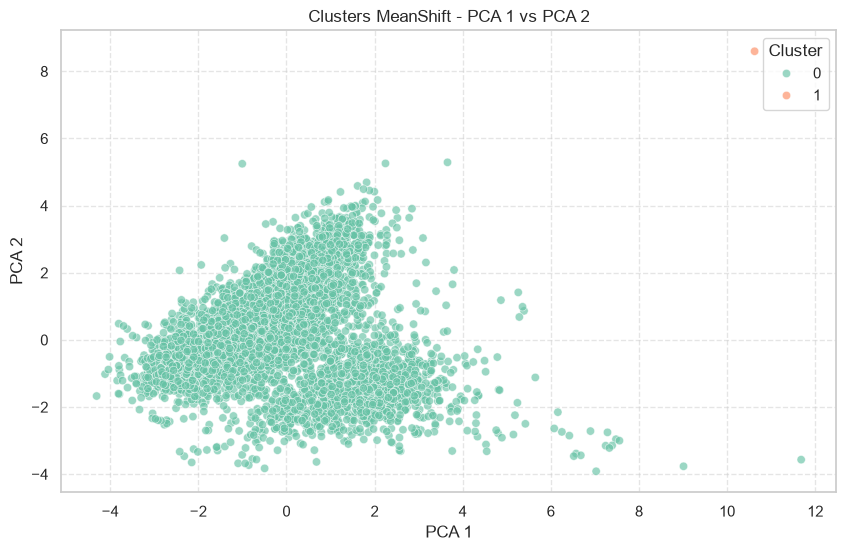

In [19]:
# Adiciona os componentes principais ao DataFrame

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster_final',
    palette='Set2',
    alpha=0.65
)

plt.title('Clusters MeanShift - PCA 1 vs PCA 2')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.021877  0.200545
residual_sugar           0.109679  0.521685
chlorides                0.411598 -0.177807
density                  0.528843  0.201136
pH                       0.006700 -0.288222
sulphates                0.283880 -0.284157
alcohol                 -0.402434 -0.322296
combined_acidity         0.419155 -0.266642
combined_sulfur_dioxide -0.133923  0.512146
quality                 -0.319675 -0.120304


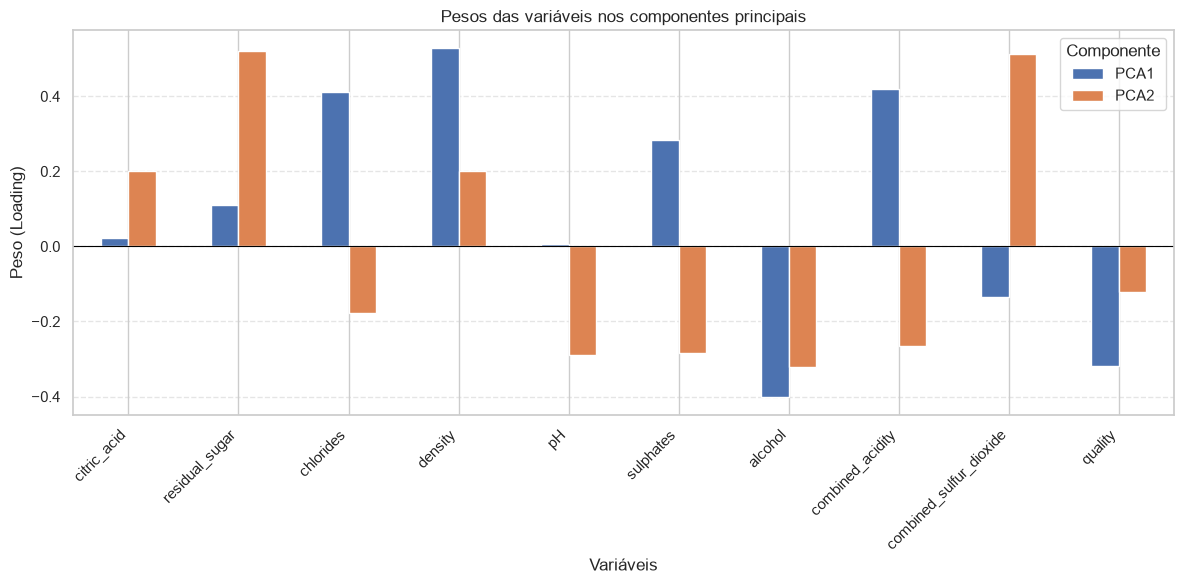

In [21]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()